# LSTM-Model-Concept 8h

#### Imports

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import datetime
import datetime
import math
import pickle

global Matplotlib standard figuresize

In [3]:
plt.rcParams['figure.figsize'] = [12, 8]

set max columns

In [4]:
pd.set_option('display.max_columns', 50)

set print options

In [5]:
np.set_printoptions(threshold=10)#np.inf

set column width

In [6]:
pd.set_option('display.max_colwidth', 50)

Get Datasets from Preprocessing

In [7]:
X = pickle.load(open("X_ds_8h.p","rb"))

In [8]:
y = pickle.load(open("y_ds_8h.p","rb"))

In [9]:
X[0]

,n_steps_in_Q,Q_size,n_added,n_removed
0,1,2361,0,0
1,2,2358,0,3
2,3,2355,0,3
3,4,2351,0,4
4,5,2348,0,3
5,6,2343,0,5
6,7,2339,0,4
7,8,2335,0,4
8,9,2333,0,2
9,10,2330,0,3


In [10]:
y[0]

0     11
1     10
2      9
3      8
4      7
5      6
6      5
7      4
8      3
9      2
10     1
Name: 1001383363, dtype: int64

## Train Test Split Sequential

Use padding as a method to make even sized sequences

In [12]:
from keras.preprocessing.sequence import pad_sequences

Using TensorFlow backend.


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
def pad(sequence, maxlen):
    # fills list post (at the end) with 0s to make even sized sequences
    return pad_sequences(sequence, maxlen=maxlen, dtype='float32', padding='post', value=0.0)

In [15]:
def split_train_test_seq(X, y, **kwargs):
    """ Splits the datasets, after padding the sequences
    to a global length
    
    Parameters:
    X : preprocessed datasets including features
    y : preprocessd datasets with target variable
    
    Returns:
    X_train : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    X_test : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    y_train : target sequences padded with 0 in shape (number of samples, timesteps, features)
    y_test : target sequences padded with 0 in shape (number of samples, timesteps, features)
    """
    # maxlen for padding
    maxlen = max(len(x) for x in y)
    
    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, **kwargs)
    
    #padding 
    X_train = pad([x.values for x in X_train], maxlen)
    X_test = pad([x.values for x in X_test], maxlen)

    #reshape for LSTM
    y_train = pad([y.values for y in y_train], maxlen)
    y_train = [x.reshape(-1,1) for x in y_train]
    y_train = np.asarray(y_train)
    
    y_test = pad([y.values for y in y_test], maxlen)
    y_test = [x.reshape(-1,1) for x in y_test]
    y_test = np.asarray(y_test)
    
    
    # for validation 
    # 0.7 * 0.2 (20% validation data from train)
    # X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.14)
    # X_val = pad([x.values for x in X_val], maxlen)
    # y_val = pad([y.values for y in y_val], maxlen)
    # y_val = [x.reshape(-1,1) for x in y_val]
    # y_val = np.asarray(y_val)
    
    
    #for train_on_batch
    #X_train = [x.reshape(1,-1,5) for x in X_train]
    #X_train = np.asarray(X_train)
    #X_test = [x.reshape(1,-1,5) for x in X_test]
    #X_test = np.asarray(X_test)
    #X_val = [x.reshape(1,-1,5) for x in X_val]
    #X_val = np.asarray(X_val)
    #, X_val, y_val
    #, X_valseq, y_valseq
    #X_valseq.shape, y_valseq.shape
    return X_train, X_test, y_train, y_test

In [16]:
X_trainseq, X_testseq, y_trainseq, y_testseq = split_train_test_seq(X, y, test_size=0.3)

In [17]:
X_trainseq.shape, X_testseq.shape

((1762, 819, 4), (756, 819, 4))

In [18]:
y_trainseq.shape, y_testseq.shape

((1762, 819, 1), (756, 819, 1))

## Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

In [45]:
n_tr, ts, d_X = X_trainseq.shape # n = number of samples, ts = number of Timesteps, d = dimension of input(Features)
n_te, ts, _ = X_testseq.shape
d_y = 1
scaler_X = StandardScaler()
X_trainseq = scaler_X.fit_transform(X_trainseq.reshape(n_tr*ts, d_X)).reshape(X_trainseq.shape)
X_testseq = scaler_X.transform(X_testseq.reshape(n_te*ts, d_X)).reshape(X_testseq.shape)
scaler_y = StandardScaler()
y_trainseq = scaler_y.fit_transform(y_trainseq.reshape(n_tr*ts, d_y)).reshape(y_trainseq.shape)
y_testseq = scaler_y.transform(y_testseq.reshape(n_te*ts, d_y)).reshape(y_testseq.shape)

no of training samples, testing samples, time steps, dimension X(Features), dimension y(Features)

In [21]:
n_tr, n_te, ts, d_X, d_y

(1762, 756, 819, 4, 1)

Samples(Rows) , Timesteps (Columns), Channels (Features)

In [22]:
X_trainseq.shape, X_testseq.shape

((1762, 819, 4), (756, 819, 4))

In [23]:
y_trainseq.shape, y_testseq.shape

((1762, 819, 1), (756, 819, 1))

## LSTM

In [24]:
from keras.models import Sequential
from keras.layers import Dense, Masking, GRU, LSTM, Dropout

In [26]:
n_steps = ts #819
n_features = d_X #4
n_neurons = 20

In [27]:
model = Sequential()
model.add(Masking(mask_value=0.0,input_shape=(n_steps, n_features))) #Masking Layer for padding 
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dense(1, input_dim=n_neurons)) #Dense Layer to generate 1Dimensional Outputs
model.compile(loss='mae', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
masking_1 (Masking)          (None, 819, 4)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 819, 20)           2000      
_________________________________________________________________
dropout_1 (Dropout)          (None, 819, 20)           0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 819, 20)           3280      
_________________________________________________________________
dense_1 (Dense)              (None, 819, 1)            21        
Total params: 5,301
Trainable params: 5,301
Non-trainable params: 0
_________________________________________________________________


In [28]:
history = model.fit(X_trainseq, y_trainseq, epochs=5, validation_split=0.2)

Train on 1409 samples, validate on 353 samples
Epoch 1/5
1409/1409 [==============================] - 287s 204ms/step - loss: 0.4545 - mae: 0.4545 - val_loss: 0.3718 - val_mae: 0.3718
Epoch 2/5
1409/1409 [==============================] - 259s 184ms/step - loss: 0.3675 - mae: 0.3675 - val_loss: 0.3617 - val_mae: 0.3617
Epoch 3/5
1409/1409 [==============================] - 261s 185ms/step - loss: 0.3608 - mae: 0.3608 - val_loss: 0.3594 - val_mae: 0.3594
Epoch 4/5
1409/1409 [==============================] - 260s 184ms/step - loss: 0.3592 - mae: 0.3592 - val_loss: 0.3558 - val_mae: 0.3558
Epoch 5/5
1409/1409 [==============================] - 258s 183ms/step - loss: 0.3561 - mae: 0.3561 - val_loss: 0.3591 - val_mae: 0.3591


## Save Model

In [29]:
model.save("model.h5")

## Load Model

In [31]:
from tensorflow.keras.models import load_model

In [32]:
model = load_model("model.h5")

#### Optional training

In [326]:
history2 = model.fit(X_trainseq, y_trainseq, epochs=2, validation_split=0.2, callbacks=[early_stop])

Train on 1409 samples, validate on 353 samples
Epoch 1/2
1409/1409 [==============================] - 130s 92ms/step - loss: 0.2622 - mae: 0.2622 - val_loss: 0.2655 - val_mae: 0.2655
Epoch 2/2
1409/1409 [==============================] - 246s 175ms/step - loss: 0.2337 - mae: 0.2337 - val_loss: 0.2821 - val_mae: 0.2821


Callbacks

In [33]:
from keras.callbacks import EarlyStopping

In [34]:
early_stop = EarlyStopping(monitor='mae', mode='min', patience=10)

#### Predicting

In [36]:
pred = model.predict(X_testseq)

#### Rescaling

Predictions 

In [37]:
y_pred = scaler_y.inverse_transform(pred.reshape(-1, 1)).reshape(pred.shape)

In [38]:
y_testresc = scaler_y.inverse_transform(y_testseq.reshape(-1, 1)).reshape(y_testseq.shape)

In [40]:
X_testresc = scaler_X.inverse_transform(X_testseq.reshape(n_te*ts, 4)).reshape(X_testseq.shape)

## Plots

A random sequence is compared

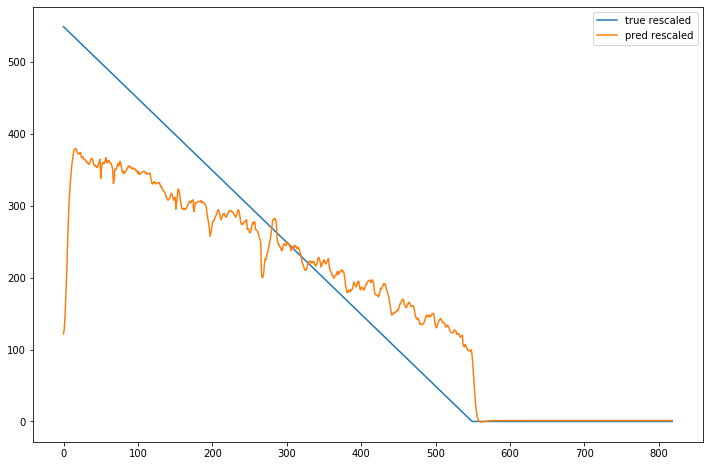

In [42]:
x = np.random.randint(len(y_testseq))
plt.plot(y_testresc[x], label='true rescaled')
plt.plot(y_pred[x], label='pred rescaled')
plt.legend()
plt.show()

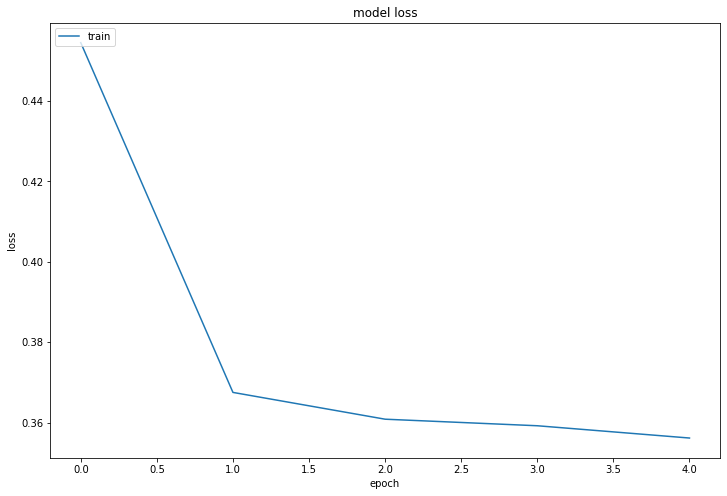

In [43]:
#plt.plot(history.history['loss'])
plt.plot(history.history['mae'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Score

Masking all entries that aren´t zero (<= 1e-4) to leave out the padded values 

In [47]:
mask = ~np.all((X_testresc.reshape(-1, d_X) <= 1e-4) & (X_testresc.reshape(-1, d_X) >= -1e-4), axis=-1)

In [49]:
from sklearn.metrics import mean_absolute_error

In [50]:
mean_absolute_error(y_testresc.reshape(-1)[mask], y_pred.reshape(-1)[mask])

139.2169